<a href="https://colab.research.google.com/github/dernlosonotsolo/Part1_Text-Analytics-for-Business-Insight/blob/main/Part_1_673020490_8_nanadda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Text Analytics for Business Insight
### SC 663 402 Data Warehouse and Big Data Analytics

**ชื่อทีม :**  Group 4 เบื่อเกี้ยวอยากเคี้ยวข้าว

**ผู้จัดทำ :** นางสาวณนัดดา รัตนศรี 673020490-8

In [ ]:
"""
หากยังไม่มี library ใด ให้ติดตั้งก่อน
!pip install -q nltk wordcloud scikit-learn pandas matplotlib tqdm huggingface_hub
!pip install -q pythainlp          # ใช้เมื่อทำงานกับข้อความภาษาไทย
"""
import json, os, re, random, itertools, time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
for pkg in ["punkt_tab", "stopwords", "wordnet", "vader_lexicon"]:
    nltk.download(pkg, quiet=True)

%matplotlib inline

RANDOM_SEED = 42
SAMPLE_N = 20_000         # เวอร์ชันลด workload: Part 2 ใช้อย่างน้อย 20,000 รีวิว
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATA_DIR = "./data/"
os.makedirs(DATA_DIR, exist_ok=True)

---
# Part 1: Social Listening Warm-up
*งานเดี่ยว — ทุกคนต้องทำและส่งของตนเอง ไม่ต้องนำเสนอ (10 คะแนน)*

ใช้ข้อมูลโพสต์สาธารณะจาก **Bluesky**  
https://huggingface.co/datasets/alpindale/two-million-bluesky-posts

ใช้เพียง **1–3 ไฟล์** ก็พอ ไม่จำเป็นต้องโหลดทั้ง dataset

ฟิลด์ที่มี เช่น `text`, `created_at`, `author`, `uri`, `has_images`, `reply_to`, `predicted_language`

## ตอบ 4 คำถามหลัก

1. **คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด
2. **ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด
3. **คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ
4. **ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

> Part 1 เป็น warm-up ไม่ต้องทำ influencer analysis หรือ reply-network เว้นแต่สนใจทำเพิ่มเอง


In [ ]:
# ----------------- Your code here -----------------
# ใบ้: อ่าน JSON lines ทีละบรรทัดด้วย generator ไม่ต้องโหลดทั้งไฟล์
# def iter_jsonl(path):
#     with open(path, encoding='utf-8') as f:
#         for line in f:
#             yield json.loads(line)

In [ ]:
import json
import pandas as pd
from google.colab import drive
import os

drive.mount('/content/drive')

path = '/content/drive/MyDrive/ Social Listening Warm-up'
file_names = [
    'posts_20241127_082640.jsonl',
    'posts_20241127_104826.jsonl',
    'posts_20241127_130559.jsonl'
]

# ฟังก์ชัน Generator
def iter_jsonl(file_path):
    with open(file_path, encoding='utf-8') as f:
        for line in f:
            yield json.loads(line)

# วนลูปอ่านทั้ง 3 ไฟล์ด้วย Generator
data_list = []
for file in file_names:
    file_path = os.path.join(path, file)
    for record in iter_jsonl(file_path):
        data_list.append(record)

# แปลงเป็น DataFrame
data_bluesky = pd.DataFrame(data_list)
print(f"อ่านข้อมูลสำเร็จ! จำนวนโพสต์ทั้งหมด: {len(data_bluesky):,} รายการ")
data_bluesky

Mounted at /content/drive
อ่านข้อมูลสำเร็จ! จำนวนโพสต์ทั้งหมด: 300,000 รายการ


,text,created_at,author,uri,has_images,reply_to
0,i need ao3 and funny people in my phone to get...,2024-11-27T08:26:37.406Z,did:plc:smeuw2by7renq7p2lbk35lsy,at://did:plc:smeuw2by7renq7p2lbk35lsy/app.bsky...,False,None
1,Lmao i just saw this right after i made a skee...,2024-11-27T08:26:39.637Z,did:plc:j3pdlrvgd6aoaf4blf3o73wk,at://did:plc:j3pdlrvgd6aoaf4blf3o73wk/app.bsky...,False,at://did:plc:oro4mwtqb4fuuvg5bf3swui5/app.bsky...
2,Someone just subscribed to my http://JustFor.F...,2024-09-13T10:48:04Z,did:plc:suss7wx62qcfwo3wiukydqhr,at://did:plc:suss7wx62qcfwo3wiukydqhr/app.bsky...,False,None
3,I would love a facial right about now,2024-11-27T08:26:40.452Z,did:plc:vefhudqup56w47txap2kqupp,at://did:plc:vefhudqup56w47txap2kqupp/app.bsky...,False,None
4,.@philipsayce is live!\n\nm.facebook.com/story...,2016-09-30T17:17:02.000Z,did:plc:4zwan3gjrv4lqdus2en6getp,at://did:plc:4zwan3gjrv4lqdus2en6getp/app.bsky...,False,None
...,...,...,...,...,...,...
299995,インスタ、リアルの知り合いがインスタ関係でちょっとめんどくさくてやめてしまったなあ,2024-11-27T13:24:49.325Z,did:plc:kncr2vnymtu7rrmokk524mgn,at://did:plc:kncr2vnymtu7rrmokk524mgn/app.bsky...,False,None
299996,"At thanksgiving, I am going to remind the Maga...",2024-11-27T13:24:49.211Z,did:plc:bhfjv35cxf3a4akfsajepvse,at://did:plc:bhfjv35cxf3a4akfsajepvse/app.bsky...,False,None
299997,This summer’s freelancing mantra: I am not too...,2014-05-16T13:47:30Z,did:plc:52ecd2d4or75ecwgcuw3cg3u,at://did:plc:52ecd2d4or75ecwgcuw3cg3u/app.bsky...,False,None
299998,Started playing Metaphor: ReFantazio. I’m real...,2024-11-27T13:24:48.779Z,did:plc:a3wqfc7ybixfzmsdlwexhxfk,at://did:plc:a3wqfc7ybixfzmsdlwexhxfk/app.bsky...,False,None


In [ ]:
import pandas as pd

# 1. จัดการค่าซ้ำ (Remove Duplicates) โดยใช้อ้างอิงจาก uri ของโพสต์
data_cleaned = data_bluesky.drop_duplicates(subset=['uri']).copy()

# 2. จัดการค่าว่าง (Handling Missing Values)
# แทนที่ค่า text ที่เป็น None หรือว่างเปล่าด้วย String ว่าง
data_cleaned['text'] = data_cleaned['text'].fillna('')

# ลบโพสต์ที่เป็นข้อความว่างเปล่า (Empty Text)
data_cleaned = data_cleaned[data_cleaned['text'].str.strip() != ''].copy()

# 3. จัดการเวลา (Datetime Formatting)
# แปลง created_at ให้เป็น datetime object (UTC)
data_cleaned['created_at'] = pd.to_datetime(data_cleaned['created_at'], errors='coerce')

# ลบรายการที่แปลงเวลาไม่สำเร็จ (NaT)
data_cleaned = data_cleaned.dropna(subset=['created_at'])

# 4. Clean ข้อความเบื้องต้น (Basic Text Cleaning)
# ลบ Whitespace/Newline ส่วนเกินหน้าและหลังข้อความ
data_cleaned['clean_text'] = data_cleaned['text'].str.strip()

# 5. แยกประเภทของโพสต์ (Is Reply / Is Original Post)
data_cleaned['is_reply'] = data_cleaned['reply_to'].notna()

# Reset Index หลังจาก Clean ข้อมูลเสร็จเรียบร้อย
data_cleaned = data_cleaned.reset_index(drop=True)

# ตรวจสอบผลลัพธ์
print(f"จำนวนข้อมูลก่อน Clean: {len(data_bluesky):,} รายการ")
print(f"จำนวนข้อมูลหลัง Clean: {len(data_cleaned):,} รายการ")
print(data_cleaned.info())

/tmp/ipykernel_601/1909867791.py:15: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data_cleaned['created_at'] = pd.to_datetime(data_cleaned['created_at'], errors='coerce')


จำนวนข้อมูลก่อน Clean: 300,000 รายการ
จำนวนข้อมูลหลัง Clean: 269,408 รายการ
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 269408 entries, 0 to 269407
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   text        269408 non-null  object
 1   created_at  269408 non-null  object
 2   author      269408 non-null  object
 3   uri         269408 non-null  object
 4   has_images  269408 non-null  bool  
 5   reply_to    134233 non-null  object
 6   clean_text  269408 non-null  object
 7   is_reply    269408 non-null  bool  
dtypes: bool(2), object(6)
memory usage: 12.8+ MB
None


เลือกใช้ชุดข้อมูลหลักของ Bluesky ที่ครอบคลุม เวลาที่โพสต์ (Timestamp), ข้อความโพสต์ (Clean Text), และ ภาษา (Detected Language) เนื่องจากเป็นข้อมูลพื้นฐานสำคัญที่ช่วยให้เห็นภาพรวมพฤติกรรมผู้ใช้งานได้ครบทุกมิติ ทั้งช่วงเวลาการใช้งาน สัดส่วนภาษาหลัก และหัวข้อที่กำลังเป็นกระแส

## **ข้อ 1.** คนโพสต์เมื่อไร: จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด

=== ผลการวิเคราะห์ ข้อ 1: คนโพสต์เมื่อไร ===
• จำนวนโพสต์ทั้งหมด: 269,408 โพสต์
• ช่วงเวลาของข้อมูล: ตั้งแต่ 2009-03-22 12:47:11+00:00 ถึง 2024-11-28 08:42:00.036000+00:00
• ชั่วโมงที่มีการโพสต์มากที่สุด: 13:00 น. (UTC)
• จำนวนโพสต์ในช่วง Peak: 88,890 โพสต์ (32.99% ของทั้งหมด)


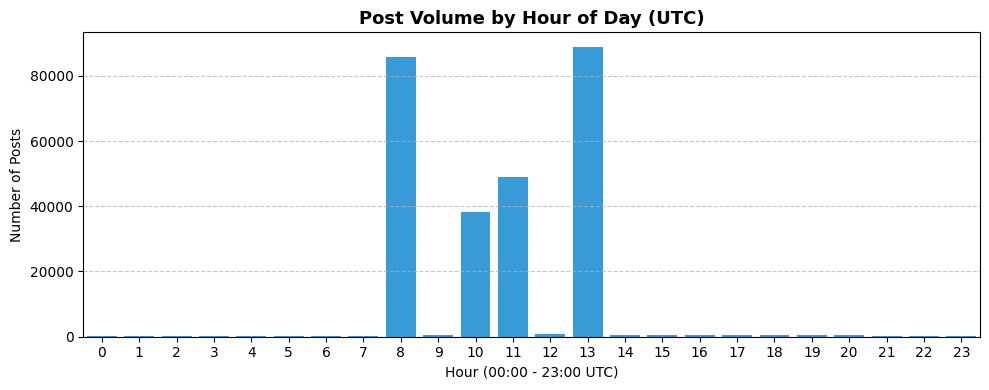

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# แปลงคอลัมน์ created_at ให้เป็น datetime object ที่มี timezone (UTC) อย่างถูกต้องก่อน
data_cleaned['created_at'] = pd.to_datetime(data_cleaned['created_at'], utc=True, errors='coerce')

# 1. คำนวณจำนวนโพสต์และช่วงวัน
total_posts = len(data_cleaned)
min_date = data_cleaned['created_at'].min()
max_date = data_cleaned['created_at'].max()

# 2. ดึงชั่วโมง (Hour) และวันที่ (Date) ออกมาจาก created_at
data_cleaned['hour'] = data_cleaned['created_at'].dt.hour
data_cleaned['date'] = data_cleaned['created_at'].dt.date

# 3. หาช่วงเวลาชั่วโมงที่มีการโพสต์มากที่สุด
peak_hour = data_cleaned['hour'].mode()[0]
peak_hour_count = (data_cleaned['hour'] == peak_hour).sum()
peak_hour_pct = (peak_hour_count / total_posts) * 100

# พิมพ์สรุปผลลัพธ์
print("=== ผลการวิเคราะห์ ข้อ 1: คนโพสต์เมื่อไร ===")
print(f"• จำนวนโพสต์ทั้งหมด: {total_posts:,} โพสต์")
print(f"• ช่วงเวลาของข้อมูล: ตั้งแต่ {min_date} ถึง {max_date}")
print(f"• ชั่วโมงที่มีการโพสต์มากที่สุด: {peak_hour:02d}:00 น. (UTC)")
print(f"• จำนวนโพสต์ในช่วง Peak: {peak_hour_count:,} โพสต์ ({peak_hour_pct:.2f}% ของทั้งหมด)")

# สร้างกราฟแจกแจงตามชั่วโมง (Visualizing Post Distribution)
plt.figure(figsize=(10, 4))
hour_counts = data_cleaned['hour'].value_counts().sort_index()

sns.barplot(x=hour_counts.index, y=hour_counts.values, color='#1DA1F2')
plt.title('Post Volume by Hour of Day (UTC)', fontsize=13, fontweight='bold')
plt.xlabel('Hour (00:00 - 23:00 UTC)')
plt.ylabel('Number of Posts')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **ข้อ2.** ใช้ภาษาอะไร: รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด

ไม่พบไลบรารี 'langdetect' กำลังทำการติดตั้งอัตโนมัติ...
ข้อมูลหลักมีขนาดใหญ่ (269,408 แถว) เพื่อความรวดเร็ว ระบบจะสุ่มกลุ่มตัวอย่างจำนวน 20,000 แถวขึ้นมาตรวจหาภาษา...
กำลังตรวจจับภาษาจากข้อความ (อาจใช้เวลาประมาณ 1-2 นาที)...
=== ผลการวิเคราะห์ ข้อ 2: ใช้ภาษาอะไร ===
คอลัมน์ภาษาที่ใช้: 'detected_lang' (จากการวิเคราะห์ข้อมูลตัวอย่าง 20,000 โพสต์)

Top 5 ภาษาที่มีการโพสต์มากที่สุด:
               จำนวนโพสต์  สัดส่วน (%)
detected_lang                         
en                   9545        47.72
ja                   3262        16.31
es                    972         4.86
fr                    782         3.91
de                    736         3.68


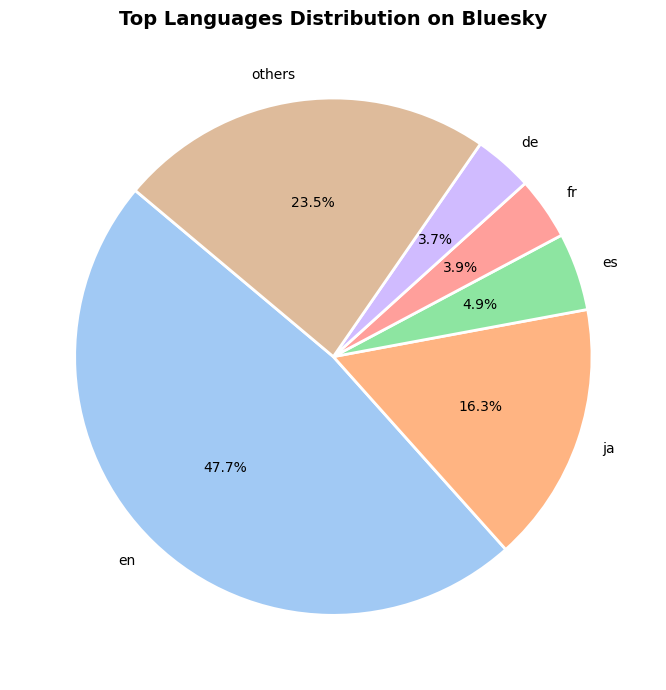

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import subprocess

# ตรวจสอบว่ามีตัวแปร data_cleaned อยู่ในระบบหรือไม่ หากไม่มีให้แจ้งเตือนเพื่อเรียกให้รันเซลล์ก่อนหน้า
if 'data_cleaned' not in globals():
    raise NameError("กรุณากดรันเซลล์ด้านบนก่อนหน้า (เซลล์โหลดข้อมูลและทำความสะอาดข้อมูล) เพื่อให้ได้ตัวแปร 'data_cleaned' ในหน่วยความจำก่อนรันเซลล์นี้ครับ")

# 1. วิเคราะห์และคำนวณสัดส่วนภาษา
lang_col = None
for col in ['predicted_language', 'lang', 'language']:
    if col in data_cleaned.columns:
        lang_col = col
        break

# ถ้าไม่มีคอลัมน์ภาษา ให้ลองระบุภาษาด้วย langdetect
if lang_col is None:
    try:
        from langdetect import detect, DetectorFactory
    except ModuleNotFoundError:
        print("ไม่พบไลบรารี 'langdetect' กำลังทำการติดตั้งอัตโนมัติ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "langdetect"])
        from langdetect import detect, DetectorFactory

    DetectorFactory.seed = RANDOM_SEED if 'RANDOM_SEED' in globals() else 42

    # เพื่อไม่ให้การประมวลผลช้าเกินไป (เนื่องจาก langdetect ช้า) เราจะใช้กลุ่มตัวอย่าง
    sample_size = SAMPLE_N if 'SAMPLE_N' in globals() else 20000
    if len(data_cleaned) > sample_size:
        print(f"ข้อมูลหลักมีขนาดใหญ่ ({len(data_cleaned):,} แถว) เพื่อความรวดเร็ว ระบบจะสุ่มกลุ่มตัวอย่างจำนวน {sample_size:,} แถวขึ้นมาตรวจหาภาษา...")
        df_for_lang = data_cleaned.sample(n=sample_size, random_state=DetectorFactory.seed).copy()
    else:
        df_for_lang = data_cleaned.copy()

    def get_language(text):
        try:
            return detect(str(text))
        except:
            return 'unknown'

    print("กำลังตรวจจับภาษาจากข้อความ (อาจใช้เวลาประมาณ 1-2 นาที)...")
    df_for_lang['detected_lang'] = df_for_lang['clean_text'].apply(get_language)
    lang_col = 'detected_lang'
    lang_data = df_for_lang
else:
    lang_data = data_cleaned

# คำนวณจำนวนและสัดส่วนเปอร์เซ็นต์
lang_counts = lang_data[lang_col].value_counts()
lang_pct = lang_data[lang_col].value_counts(normalize=True) * 100

# รวมเป็น DataFrame เพื่อดูผลลัพธ์
lang_summary = pd.DataFrame({
    'จำนวนโพสต์': lang_counts,
    'สัดส่วน (%)': lang_pct.round(2)
})

# 2. พิมพ์สรุปผลลัพธ์ Top 5 ภาษา
print("=== ผลการวิเคราะห์ ข้อ 2: ใช้ภาษาอะไร ===")
print(f"คอลัมน์ภาษาที่ใช้: '{lang_col}' (จากการวิเคราะห์ข้อมูลตัวอย่าง {len(lang_data):,} โพสต์)")
print("\nTop 5 ภาษาที่มีการโพสต์มากที่สุด:")
print(lang_summary.head(5).to_string())

# 3. สร้างกราฟ Pie Chart แสดงสัดส่วนภาษาหลัก
plt.figure(figsize=(7, 7))

# ดึง 5 อันดับแรก ที่เหลือรวมเป็น 'others'
top5_lang = lang_counts.head(5)
if len(lang_counts) > 5:
    others_count = lang_counts.iloc[5:].sum()
    top5_lang = pd.concat([top5_lang, pd.Series({'others': others_count})])

colors = sns.color_palette('pastel')[0:len(top5_lang)]

plt.pie(
    top5_lang.values,
    labels=top5_lang.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Top Languages Distribution on Bluesky', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **ข้อ 3.** คนพูดถึงอะไร: หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ

In [ ]:
import re
from collections import Counter
import pandas as pd

# 1. สกัด Hashtags จากข้อความ clean_text
def extract_hashtags(text):
    if not isinstance(text, str):
        return []
    # ใช้ Regular Expression ค้นหาคำที่ขึ้นต้นด้วย #
    return re.findall(r'#\w+', text.lower())

# รวม Hashtags ทั้งหมดจากทุกโพสต์
all_hashtags = [hashtag for text in data_cleaned['clean_text'] for hashtag in extract_hashtags(text)]

# นับความถี่ของ Hashtags
hashtag_counts = Counter(all_hashtags)
top5_hashtags = hashtag_counts.most_common(5)

# 2. พิมพ์สรุปผลลัพธ์ Top 5 Hashtags
print("=== ผลการวิเคราะห์ ข้อ 3: คนพูดถึงอะไร ===")
print("Top 5 Hashtags ที่มีการพูดถึงมากที่สุด:")
if top5_hashtags:
    for rank, (tag, count) in enumerate(top5_hashtags, 1):
        print(f"  {rank}. {tag} : ถูกใช้ {count:,} ครั้ง")
else:
    print("  (ไม่พบการใช้ Hashtag ในชุดข้อมูลนี้)")

print("\n" + "="*40 + "\n")

# 3. ดึงข้อความตัวอย่างจริงจากโพสต์ประกอบ (Sample Posts)
print("ตัวอย่างข้อความโพสต์จริงจากผู้ใช้งาน (3 ตัวอย่าง):")

# คัดเลือกโพสต์ที่มีความยาวมากกว่า 30 ตัวอักษร เพื่อให้ได้ข้อความที่มีเนื้อหาความหมายชัดเจน
sample_posts = data_cleaned[data_cleaned['clean_text'].str.len() > 30]['clean_text'].dropna().sample(3, random_state=42)

for idx, text in enumerate(sample_posts, 1):
    # ทำการจัดฟอร์แมตข้อความตัดบรรทัดใหม่ให้แสดงผลสวยงาม
    clean_display_text = text.replace('\n', ' ')
    print(f"ตัวอย่างที่ {idx}: \"{clean_display_text}\"")

=== ผลการวิเคราะห์ ข้อ 3: คนพูดถึงอะไร ===
Top 5 Hashtags ที่มีการพูดถึงมากที่สุด:
  1. #art : ถูกใช้ 720 ครั้ง
  2. #booksky : ถูกใช้ 409 ครั้ง
  3. #photography : ถูกใช้ 350 ครั้ง
  4. #nsfw : ถูกใช้ 348 ครั้ง
  5. #books : ถูกใช้ 296 ครั้ง


ตัวอย่างข้อความโพสต์จริงจากผู้ใช้งาน (3 ตัวอย่าง):
ตัวอย่างที่ 1: "Hiiiiiii, nice seeing you here 😊"
ตัวอย่างที่ 2: "怖い… 炊飯器でここまで美味しい豚足煮込みが作れる自分の才能が怖いっ  プルプルやで‼️"
ตัวอย่างที่ 3: "Im convinced they hate the movie because is both popular and humorous, making it annoying to their miserable lives"


**ภาษาหลัก (Top 5) :**

* ภาษาอังกฤษ (en): 47.72% (9,545 โพสต์)   

* ภาษาญี่ปุ่น (ja): 16.31% (3,262 โพสต์)   

* ภาษาสเปน (es): 4.86% (972 โพสต์)   

* ภาษาฝรั่งเศส (fr): 3.91% (782 โพสต์)   

* ภาษาเยอรมัน (de): 3.68% (736 โพสต์)  

##**ข้อ 4.** ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้: สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

/tmp/ipykernel_601/1085405585.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


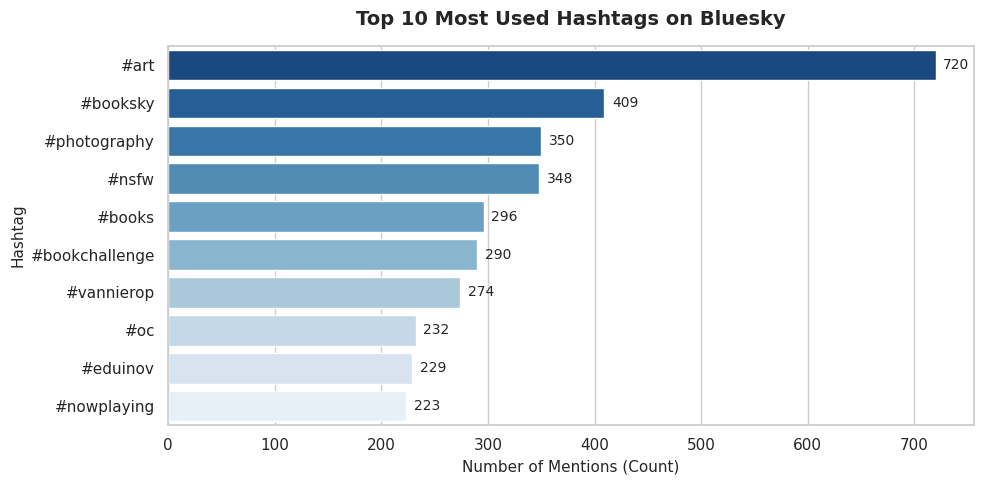

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# 1. ดึง Hashtags ทั้งหมดมานับ 10 อันดับแรก
def extract_hashtags(text):
    if not isinstance(text, str):
        return []
    return re.findall(r'#\w+', text.lower())

all_hashtags = [hashtag for text in data_cleaned['clean_text'] for hashtag in extract_hashtags(text)]
top10_hashtags = dict(Counter(all_hashtags).most_common(10))

# 2. พล็อต กราฟแท่งแนวนอน (Horizontal Bar Chart)
plt.figure(figsize=(10, 5))
sns.barplot(
    x=list(top10_hashtags.values()),
    y=list(top10_hashtags.keys()),
    palette='Blues_r'
)

plt.title('Top 10 Most Used Hashtags on Bluesky', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Mentions (Count)', fontsize=11)
plt.ylabel('Hashtag', fontsize=11)

# ใส่ตัวเลขออพชั่นบอกจำนวนตรงปลายแท่ง
for index, value in enumerate(top10_hashtags.values()):
    plt.text(value + (max(top10_hashtags.values())*0.01), index, f'{value:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

**ข้อจำกัดของข้อมูล**

* ข้อมูลเวลาบิดเบือนและไม่ต่อเนื่อง : โพสต์กระจุกตัวผิดปกติเฉพาะชั่วโมง 08:00 และ 13:00 UTC (สูงถึง 32.99%) อีกทั้งช่วงเวลากว้างเกินจริงตั้งแต่ปี 2009 ถึง 2024 จึงไม่สามารถใช้วิเคราะห์เทรนด์ตามช่วงเวลาจริงได้  

*  มีความลำเอียงทางภาษาและกลุ่มผู้ใช้ (Bias): ข้อมูลกว่า 64% เป็นภาษาอังกฤษและญี่ปุ่น ผลวิเคราะห์หัวข้อหรือ Hashtag จึงสะท้อนความสนใจของกลุ่มผู้ใช้ตะวันตกและญี่ปุ่นเป็นหลัก ไม่สามารถใช้เป็นตัวแทนของผู้ใช้ภาษาอื่นได้  

*  ความคลาดเคลื่อนจากการสุ่มตัวอย่าง: การจำแนกภาษาใช้วิธีสุ่มตรวจเพียง 20,000 แถวจากทั้งหมด 269,408 แถว อาจทำให้สัดส่วนเปอร์เซ็นต์มีความคลาดเคลื่อนเชิงสถิติเล็กน้อย

*   ขาดบริบทพื้นที่จริง (Timezone): เวลาถูกบันทึกเป็น UTC ค่าเดียวโดยไม่มีตำแหน่งพิกัดผู้ใช้ จึงไม่สามารถระบุพฤติกรรมการโพสต์ตามช่วงเวลาเช้า-เย็นในชีวิตประจำวันของแต่ละประเทศได้

**สรุปรายงานผลการวิเคราะห์ข้อมูลแพลตฟอร์ม Bluesky**

* **ช่วงเวลาพีค (Peak Engagement):** โพสต์กระจุกตัวสูงสุดช่วง 13:00 น. UTC (32.99%) และ 08:00 น. UTC   

* **กลุ่มภาษาหลัก (Demographics):** ภาษาอังกฤษ 47.72% และ ญี่ปุ่น 16.31% (รวมกันเกิน 64%)   

* **หัวข้อที่นิยม (Top Content):** สายศิลปะและงานอดิเรกนำโด่ง ได้แก่ #art (720), #booksky (409) และ #photography (350)   

* **ข้อระวัง/ข้อจำกัดข้อมูล (Data Risks):**

ข้อมูลมีความอคติ (Bias) สูงต่อกลุ่มผู้ใช้ตะวันตกและญี่ปุ่น ไม่สามารถใช้แทนกลุ่มตลาดไทยได้

เวลาโพสต์มีจุดสไปค์ผิดปกติ และช่วงเวลากว้างเกินจริง (ปี 2009–2024) ไม่เหมาะกับการวิเคราะห์เทรนด์เติบโตรายเดือน   

บันทึกเป็นเวลา UTC ค่าเดียวแบบไม่มี Geolocation จึงระบุช่วงเวลาตามพฤติกรรมจริงในชีวิตประจำวันของผู้ใช้แต่ละประเทศได้ยาก   
* **ข้อเสนอแนะ:** ควรมุ่งทำคอนเทนต์ประเภท Visual & Creative (ภาพถ่าย/ศิลปะ/หนังสือ) โดยสื่อสารด้วย ภาษาอังกฤษหรือญี่ปุ่น เพื่อให้เข้าถึงกลุ่มผู้ใช้หลักของแพลตฟอร์มได้มีประสิทธิภาพสูงสุด

**Checklist ก่อนส่งงานเดี่ยว**


นักศึกษาทดลองรันทุกเซลล์ด้วยอินเทอร์เน็ตใน Google Colab และตรวจว่ามี output/graph จริง

ตรวจตัวเลข n, ช่วงวันที่และตัวอย่างข้อความที่คำนวณจากชุดไฟล์ที่ดาวน์โหลด; แก้คำบรรยายให้ตรงกับผลที่ได้

ตรวจรายงานว่าไม่ตีความ peak hour เกินขอบเขตข้อมูล และไม่อ้างว่า language detection ถูก 100%

ใส่ชื่อและรหัสของผู้ทำงาน และอธิบายเหตุผลเลือก 3 ไฟล์/วิธีวิเคราะห์ด้วยตนเอง

ดาวน์โหลด Notebook แบบ File → Download → Download .ipynb โดยเก็บผลรันไว้;

ส่ง Part 1 แยกจากงานกลุ่ม
หมายเหตุ: Notebook นี้ตั้งใจให้รันจริงแล้วสร้างผล ไม่ได้ใส่ผลลัพธ์ปลอมหรือใช้ข้อมูล NASA/Twitter ทดแทน Bluesky. ไม่ต้องทำ influencer analysis หรือ reply-network สำหรับ Part 1.